In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


# IMPORTS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.feature_selection import chi2, SelectKBest

In [3]:
data= pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv") 

# EDA

In [4]:
data.head(3)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,No


In [5]:
data.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [6]:
data.dtypes

id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [8]:
print(data.duplicated().sum())

0


In [9]:
data.drop('id', axis= 1, inplace= True)
target= data['Churn']
target= target.map({'Yes': 1, 'No': 0}).astype(int)

In [10]:
# columns with numerical datatype
num_cols= []
for col in data.columns:
    if data[col].dtypes == 'int64' or data[col].dtypes == 'float64':
        num_cols.append(col)
print("Numerical Values:", num_cols)
print('-' * 100)
# columns with 'object' datatype
obj_cols= []
for col in data.columns:
    if data[col].dtypes == 'object':
        obj_cols.append(col)
print("Categorical Values:", obj_cols)

Numerical Values: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
----------------------------------------------------------------------------------------------------
Categorical Values: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [11]:
for col in num_cols:
    print(f'{col}: {data[col].unique()}')

SeniorCitizen: [0 1]
tenure: [29 58  1 24 72 55 13 67 33 63  3 31 27 52 68 35 66 17 59 61 12 37 64 23
  9  8 15 18 19 51  5 71 60 62 45 69 40 53 54 34  2 70 39 41  4 22 46 28
 42 48 21 43 14 10 47  7 57 36 16 26 20 50 30 11 44 25 56  6 65 38 49 32]
MonthlyCharges: [ 60.1   69.5  100.4  ...  18.45 112.05  46.15]
TotalCharges: [1653.85 3778.2  5841.35 ... 1478.9  1284.75 5460.7 ]


From the output above, 'SeniorCitizen' feature has binary values, while other numerical features have continuous values. We will leave them as it is for now.

In [12]:
for col in obj_cols:
    print(f'{col}: {data[col].unique()}')
    

gender: ['Male' 'Female']
Partner: ['Yes' 'No']
Dependents: ['Yes' 'No']
PhoneService: ['Yes' 'No']
MultipleLines: ['No' 'Yes' 'No phone service']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['Yes' 'No' 'No internet service']
OnlineBackup: ['No' 'Yes' 'No internet service']
DeviceProtection: ['Yes' 'No' 'No internet service']
TechSupport: ['Yes' 'No' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['One year' 'Two year' 'Month-to-month']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']
Churn: ['No' 'Yes']


# Preprocessing

In [13]:
def binary_mapping(col):
    mapping= {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
    return col.map(mapping).fillna(0).astype(int)

def service_mapping(col):
    col.replace({'No internet service': 'No', 'No phone service': 'No'})
    mapping= {'Yes': 1, 'No': 0}
    return col.map(mapping).fillna(0).astype(int)

def nominal_mapping(data, cols):
    return  pd.get_dummies(data, columns= nominal_cols, drop_first= True, dtype= int)
    

In [14]:
binary_cols= ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    data[col]= binary_mapping(data[col])

In [15]:
service_cols= ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingMovies', 'StreamingTV', 'MultipleLines']
for col in service_cols:
    data[col]= service_mapping(data[col])

In [16]:
nominal_cols= ['Contract', 'InternetService', 'PaymentMethod']
data= nominal_mapping(data, nominal_cols)

In [17]:
data.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,1,29,1,0,1,0,1,...,60.1,1653.85,No,1,0,0,0,0,0,1
1,1,0,1,1,58,1,0,1,1,0,...,69.5,3778.20,No,0,1,0,0,1,0,0
2,1,0,1,0,58,1,1,0,1,0,...,100.4,5841.35,No,0,0,1,0,0,1,0


# Visualization

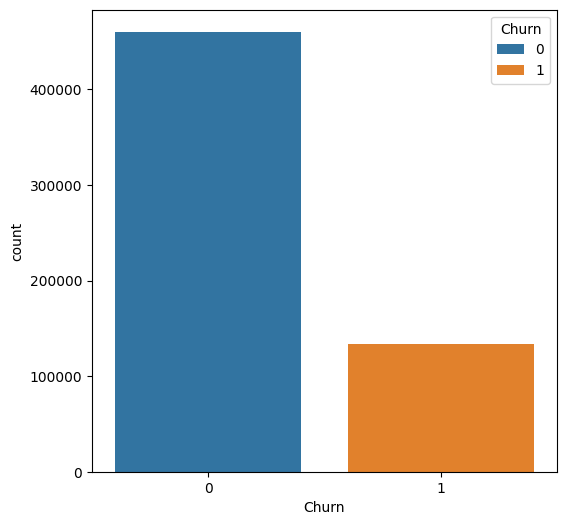

In [18]:
plt.figure(figsize= (6, 6))
sns.countplot(x=target, hue= target)
plt.show()

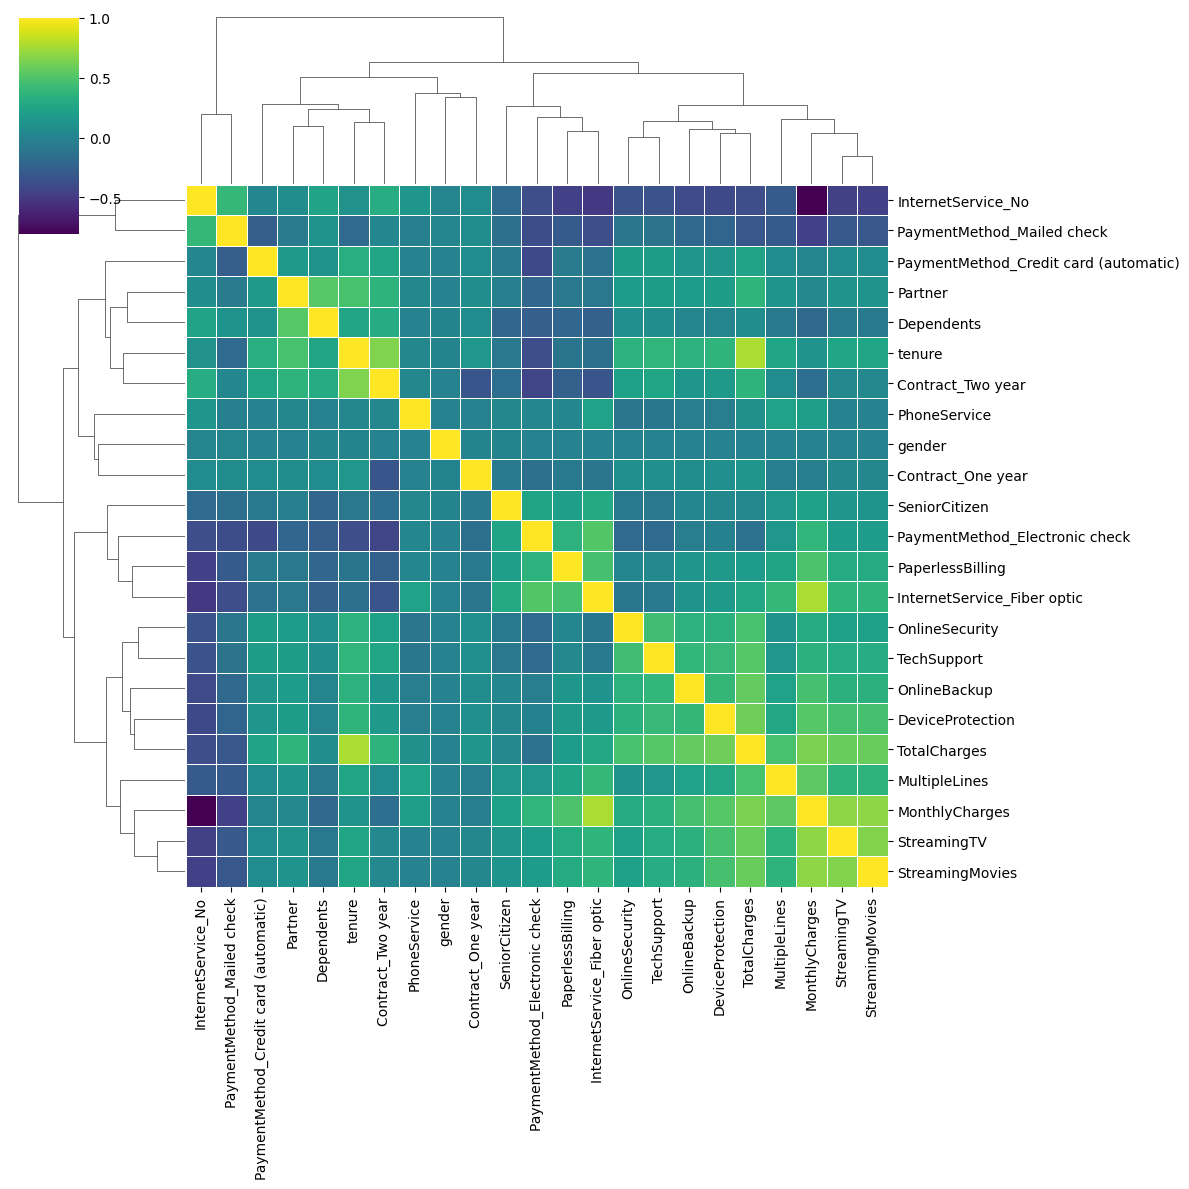

In [19]:
feature_corr= data.drop('Churn', axis= 1).corr()

clustermap= sns.clustermap(feature_corr, annot= False, cmap= 'viridis', figsize= (12, 12), linewidth= 0.5)

In [20]:
data['Churn']= target

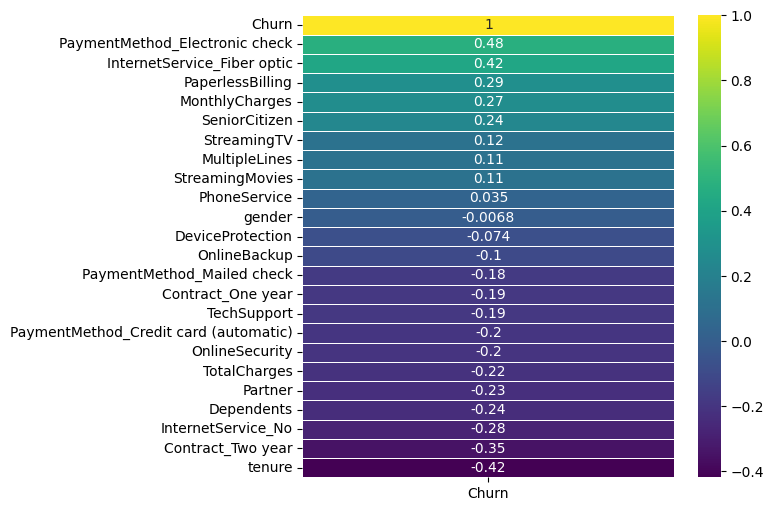

In [21]:
target_corr= data.corr()['Churn'].sort_values(ascending= False).to_frame()

plt.figure(figsize= (6, 6))
sns.heatmap(target_corr, annot= True, cmap= 'viridis', linewidth= 0.5)
plt.show()

In [22]:
original_features= data.drop('Churn', axis= 1)
y= data['Churn']

selector= SelectKBest(chi2, k= 12)
X_new= selector.fit_transform(original_features, y)

selected_features= original_features.columns[selector.get_support()]
print(selected_features)

Index(['SeniorCitizen', 'Dependents', 'tenure', 'OnlineSecurity',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Contract_Two year', 'InternetService_Fiber optic',
       'InternetService_No', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check'],
      dtype='object')


Though we already have our best selected features after using Chi-Square test, we can also use the following method to select features based on threshold values of correlation with target.

In [23]:
threshold= 0.5
corr_matrix= data.drop(columns=['Churn']).corr().abs()

to_drop= set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):

        if corr_matrix.iloc[i, j] > threshold:
            col_i= corr_matrix.columns[i]
            col_j= corr_matrix.columns[j]

            if abs(data[col_i].corr(data['Churn'])) > abs(data[col_j].corr(data['Churn'])):
                to_drop.add(col_j)
            else:
                to_drop.add(col_i)
print(list(to_drop))


['MultipleLines', 'Contract_Two year', 'StreamingMovies', 'InternetService_No', 'TotalCharges', 'DeviceProtection', 'OnlineBackup', 'Partner', 'InternetService_Fiber optic', 'TechSupport', 'MonthlyCharges', 'StreamingTV']


In [24]:
X_selected= data[selected_features]
y= data['Churn']

X_train, X_test, y_train, y_test= train_test_split(X_selected, y, test_size= 0.2, stratify= y, random_state= 7)

In [25]:
model= XGBClassifier(random_state= 7)

model.fit(X_train, y_train)
preds= model.predict(X_test)

In [26]:
print(classification_report(y_test, preds))
print('-' * 100)

y_prob = model.predict_proba(X_test)[:,1]
print(f'{roc_auc_score(y_test, y_prob)}')

              precision    recall  f1-score   support

           0       0.90      0.92      0.91     92076
           1       0.71      0.63      0.67     26763

    accuracy                           0.86    118839
   macro avg       0.80      0.78      0.79    118839
weighted avg       0.85      0.86      0.86    118839

----------------------------------------------------------------------------------------------------
0.9131316997429544


In [27]:
test_data= pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")

In [28]:
id_s= test_data['id']
test_data.drop('id', axis= 1, inplace= True)
for col in test_data.columns:
    if col in binary_cols:
        test_data[col]= binary_mapping(data[col])
    elif col in service_cols:
        test_data[col]= service_mapping(test_data[col])
        
test_data= nominal_mapping(test_data, nominal_cols)

In [29]:
test_data= test_data[selected_features]

In [30]:
test_preds= model.predict(test_data)
test_prob = model.predict_proba(test_data)[:,1]

In [31]:
submission = pd.DataFrame({
    "id": id_s, "Churn": test_prob
})

In [32]:
submission.to_csv("submission.csv", index=False)